### Name: Nitish Dhinaharan
#### Course: MSCS-634 Advanced Big Data and Data Mining
#### Project Deliverable 2: Regression Modeling and Performance Evaluation

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import cross_val_score

In [3]:
# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Clean data (reuse logic from D1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

print(df.shape)
df.head()

(7043, 21)


/tmp/ipython-input-2180515867.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Feature Engineering

In [4]:
# Feature creation: count total subscribed services
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Convert categorical columns to appropriate types
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # ID not useful
cat_cols.remove('Churn')       # classification label, not used here

num_cols = ['tenure', 'TotalCharges', 'num_services']

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['tenure', 'TotalCharges', 'num_services']


#### Train/Test split

In [5]:
X = df[cat_cols + num_cols]
y = df['MonthlyCharges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Regression Models - Build, train and evalute

In [6]:
# Define transformers
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numeric_transformer = StandardScaler()

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, cat_cols),
        ('num', numeric_transformer, num_cols)
    ]
)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}

In [9]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    pipe.fit(X_train, y_train)

    # Predictions
    y_pred = pipe.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Cross-validation
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()

    results.append({
        "Model": name,
        "R²": round(r2, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "CrossVal R²": round(cv_r2, 3)
    })

# Display results as a DataFrame
results_df = pd.DataFrame(results)
print("Model Performance Summary:")
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.316e+03, tolerance: 5.100e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.040e+03, tolerance: 4.113e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.026e+03, tolerance: 4.096e

Model Performance Summary:


,Model,R²,MSE,RMSE,CrossVal R²
0,Linear Regression,0.999,1.098,1.048,0.999
1,Ridge Regression,0.999,1.098,1.048,0.999
2,Lasso Regression,0.999,1.104,1.051,0.999


#### Visualization of Model Performance

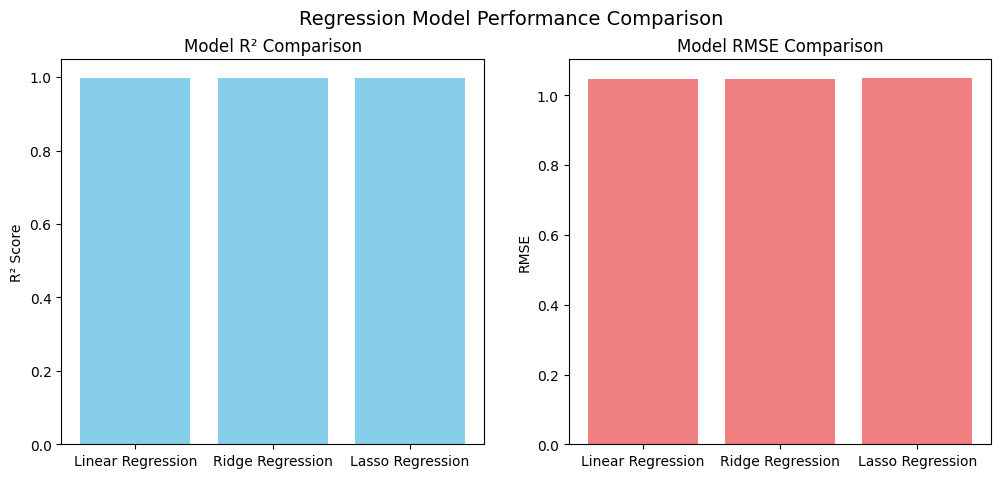

In [10]:
# Plot R² and RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# R² comparison
axes[0].bar(results_df['Model'], results_df['R²'], color='skyblue')
axes[0].set_title('Model R² Comparison')
axes[0].set_ylabel('R² Score')

# RMSE comparison
axes[1].bar(results_df['Model'], results_df['RMSE'], color='lightcoral')
axes[1].set_title('Model RMSE Comparison')
axes[1].set_ylabel('RMSE')

plt.suptitle('Regression Model Performance Comparison', fontsize=14)
plt.show()

In [11]:
best_model = results_df.loc[results_df['R²'].idxmax()]
print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model          Linear Regression
R²                         0.999
MSE                        1.098
RMSE                       1.048
CrossVal R²                0.999
Name: 0, dtype: object
